## Hi! Here is the new playground, go ahead and explore the dataset and find out as many insights as you can before jumping to the ML part! 

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('./dataset/housing.csv')
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [44]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20640
Number of columns: 10


In [45]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

## Dataset Overview

The dataset contains 20,640 observations and 10 features describing
geographical, demographic and economic characteristics of housing areas
in California.

The target variable is median_house_value, which represents the median
house value recorded for each area.

## Dataset Column Description

The dataset contains geographical, demographic and economic information about housing areas in California. Each row represents a geographical area rather than a single house.

### `longitude`

* Represents the geographical longitude of the housing area.
* Longitude indicates the east–west position of the area.
* More negative values generally represent locations farther west.
* This feature can help identify areas located closer to the California coast.

### `latitude`

* Represents the geographical latitude of the housing area.
* Latitude indicates the north–south position of the area.
* Higher values represent locations farther north.
* Together with longitude, this feature describes the geographical location of each housing area.

### `housing_median_age`

* Represents the median age of the houses located in the area.
* It does not represent the age of one individual house.
* A higher value means that the houses in that area are generally older.
* The maximum value of 52 may indicate that the feature was capped at an upper limit.

### `total_rooms`

* Represents the total number of rooms in all houses from the geographical area.
* It does not represent the number of rooms in a single house.
* Areas containing more households generally also have a larger number of total rooms.
* This feature may become more informative when divided by the number of households.

### `total_bedrooms`

* Represents the total number of bedrooms in all houses from the area.
* This is the only original feature containing missing values in the dataset.
* The missing observations can be replaced with the median value during data preprocessing.
* This feature is strongly related to `total_rooms`.

### `population`

* Represents the total number of people living in the geographical area.
* It describes the size of the local population.
* A large population does not necessarily indicate expensive housing.
* The feature may be more informative when divided by the number of households.

### `households`

* Represents the total number of households located in the area.
* A household usually refers to a group of people living in the same housing unit.
* This feature helps describe the size of the geographical area.
* It can be used to calculate average values per household.

### `median_income`

* Represents the median income of households in the area.
* The values are expressed in tens of thousands of dollars.
* For example, a value of `4.5` represents a median income of approximately **45,000 dollars**.
* This feature has one of the strongest relationships with the median house value.
* Areas with higher median income generally tend to have more expensive houses.

### `ocean_proximity`

* Represents the position of the housing area relative to the ocean.
* It is the only categorical feature in the original dataset.
* Its possible categories include:

  * `<1H OCEAN` – located less than one hour from the ocean;
  * `INLAND` – located in an inland area;
  * `NEAR OCEAN` – located near the ocean;
  * `NEAR BAY` – located near a bay;
  * `ISLAND` – located on an island.
* Coastal areas generally have higher house values than inland areas.
* This feature must be encoded before it can be used by most machine-learning models.

### `median_house_value`

* Represents the median value of houses in the geographical area.
* It represents the median house value in the area, not the value of one individual house.
* The maximum recorded value is `500001'.

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [55]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_rows)

Number of duplicated rows: 0


- The dataset does not contain duplicated observations, so no rows need
  to be removed because of complete duplication.

In [56]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

total_bedrooms    207
dtype: int64

In [57]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percentage

total_bedrooms        1.002907
longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [58]:
missing_bedrooms_percentage = (
    df["total_bedrooms"].isnull().mean() * 100
)

print(
    f"Missing total_bedrooms values: "
    f"{missing_bedrooms_percentage:.2f}%"
)

Missing total_bedrooms values: 1.00%


In [59]:
df_eda = df.copy()

In [60]:
bedrooms_median = df_eda["total_bedrooms"].median()

df_eda["total_bedrooms"] = (
    df_eda["total_bedrooms"].fillna(bedrooms_median)
)

print("Median used:", bedrooms_median)
print(df_eda.isnull().sum())

Median used: 435.0
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


## Conclusions

- `total_bedrooms` is the only feature containing missing values.
  
- It contains 207 missing observations, representing approximately 1%
  of the complete dataset.

- Since the percentage is relatively small, the observations do not
  need to be removed.

- The missing values were replaced with the median number of bedrooms.

- The median was selected because it is less sensitive to extreme
  values than the arithmetic mean.

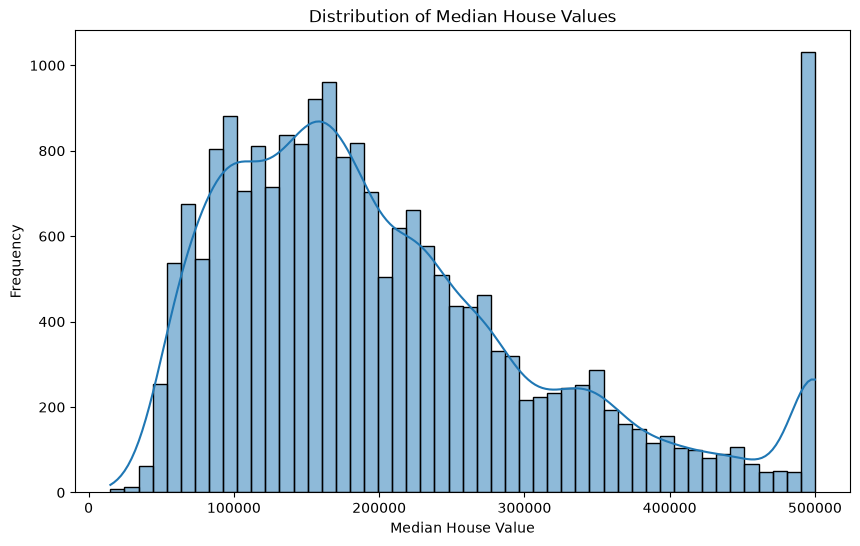

In [61]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x="median_house_value",
    bins=50,
    kde=True
)

plt.title("Distribution of Median House Values")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

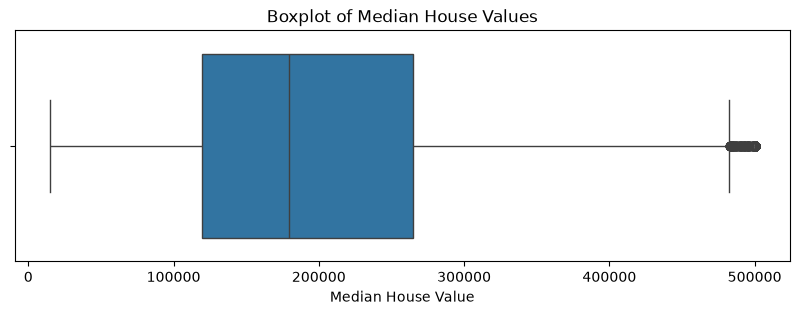

In [63]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df_eda,
    x="median_house_value"
)

plt.title("Boxplot of Median House Values")
plt.xlabel("Median House Value")
plt.show()

## Conclusions

- The mean house value is higher than the median, which confirms the
  influence of expensive housing areas.

- This suggests that the target variable may have been capped at an
  upper limit.

- The real values of these observations may be higher than the recorded
  value.

In [67]:
ocean_counts = (
    df_eda["ocean_proximity"]
    .value_counts()
)

ocean_counts

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

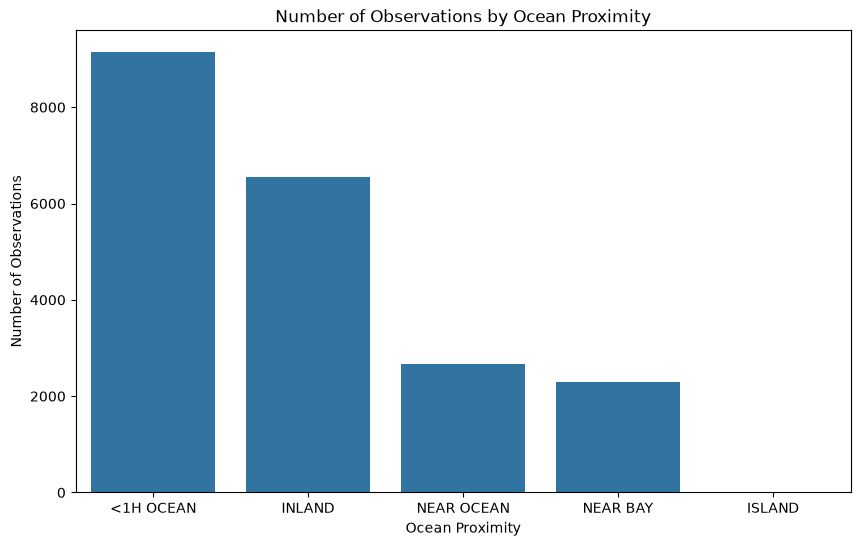

In [68]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_eda,
    x="ocean_proximity",
    order=ocean_counts.index
)

plt.title("Number of Observations by Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Number of Observations")
plt.show()

In [69]:
ocean_percentage = (
    df_eda["ocean_proximity"]
    .value_counts(normalize=True)
    .mul(100)
)

ocean_percentage

ocean_proximity
<1H OCEAN     44.263566
INLAND        31.739341
NEAR OCEAN    12.877907
NEAR BAY      11.094961
ISLAND         0.024225
Name: proportion, dtype: float64

In [70]:
ocean_price_statistics = (
    df_eda
    .groupby("ocean_proximity")["median_house_value"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

ocean_price_statistics

,count,mean,median,min,max
ocean_proximity,,,,,
ISLAND,5,380440.000000,414700.0,287500.0,450000.0
NEAR BAY,2290,259212.311790,233800.0,22500.0,500001.0
NEAR OCEAN,2658,249433.977427,229450.0,22500.0,500001.0
<1H OCEAN,9136,240084.285464,214850.0,17500.0,500001.0
INLAND,6551,124805.392001,108500.0,14999.0,500001.0


## Conclusions on Ocean Proximity

- The `<1H OCEAN` category contains the largest number of observations, representing approximately **44%** of the dataset.

- The `INLAND` category is the second-largest group, representing approximately **32%** of the observations.

- The `ISLAND` category contains only **5 observations**, so its statistical results are not representative and should be interpreted carefully.

- The distribution of observations across the ocean-proximity categories is unbalanced.

- The `ISLAND` category has the highest average house value, but this result is unreliable because of the very small number of observations.

- Among the well-represented categories, houses located `NEAR BAY` and `NEAR OCEAN` have the highest average values.

- The `INLAND` category has the lowest average house value, showing that inland houses are generally cheaper than houses located closer to the coast.

- Overall, ocean proximity appears to be an important feature for house value, although it should be interpreted together with median income, geographical location and housing characteristics.


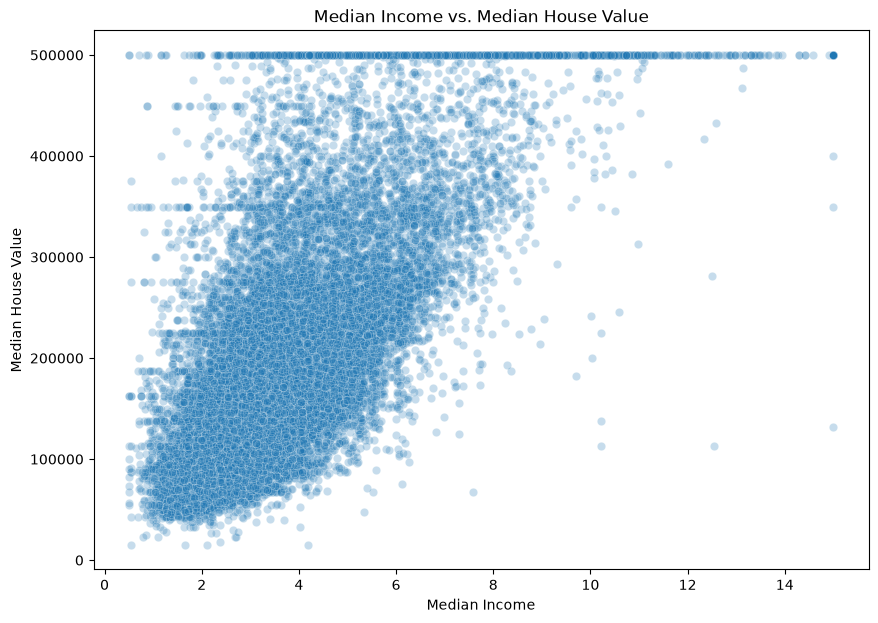

In [71]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_eda,
    x="median_income",
    y="median_house_value",
    alpha=0.25
)

plt.title("Median Income vs. Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

## Conclusions on Median Income vs. Median House Value

- There is a clear positive relationship between median income and median house value.

- As the median income of an area increases, the median house value generally increases as well.

- Areas with low median income are mainly concentrated in the lower and medium house-value ranges.

- Areas with high median income generally have more expensive houses, although some variation can still be observed.

- Median income appears to be one of the most important numerical features for estimating house value.

- Median income alone cannot completely determine house value because geographical location, ocean proximity, housing age and household characteristics also influence the price.

- Overall, the graph suggests a strong association between the economic level of an area and its housing prices, but this relationship does not prove direct causation.

For easier interpretation, the continuous median income feature is divided
into five manually defined income categories. These categories are created
only for exploratory analysis.

In [72]:
df_eda["income_category"] = pd.cut(
    df_eda["median_income"],
    bins=[0, 2, 4, 6, 8, np.inf],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [74]:
income_category_stats = (
    df_eda
    .groupby(
        "income_category",
        observed=False
    )["median_house_value"]
    .agg(["count", "mean", "median"])
)

income_category_stats

,count,mean,median
income_category,,,
Very Low,2457,112497.156695,93300.0
Low,10096,168199.345880,153100.0
Medium,5725,244635.195284,226800.0
High,1672,344844.687201,335900.0
Very High,690,460639.334783,500001.0


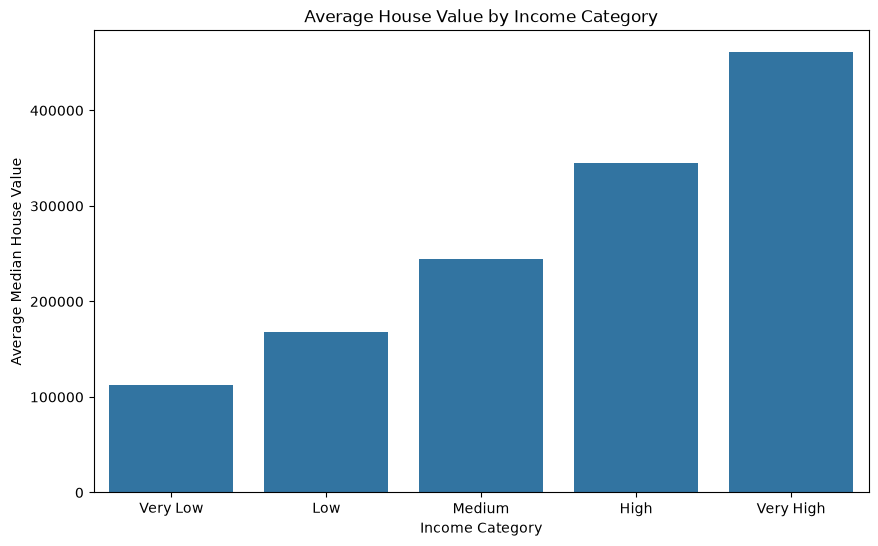

In [75]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_eda,
    x="income_category",
    y="median_house_value",
    errorbar=None
)

plt.title("Average House Value by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Average Median House Value")
plt.show()

## Conclusions on Average House Value by Income Category

- The average house value increases progressively from the `Very Low` income category to the `Very High` income category.

- Areas classified as `Very Low` or `Low` income generally have the lowest average house values.

- Areas with `Medium` income have noticeably higher average house values than the lower-income categories.

- The `High` and `Very High` income categories contain the most expensive housing areas on average.

- The difference between the categories confirms the positive relationship previously observed between median income and median house value.

- Grouping income values into categories makes the general trend easier to interpret than the scatterplot, although it removes some individual variation.

- Overall, income category appears to be a useful feature for describing differences in house values, but location and other housing characteristics must also be considered.


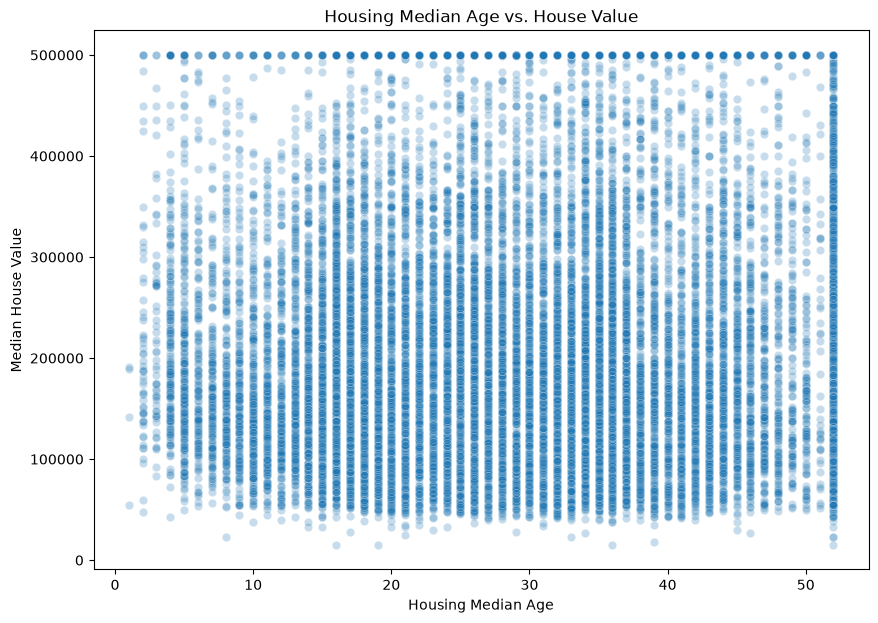

In [76]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_eda,
    x="housing_median_age",
    y="median_house_value",
    alpha=0.25
)

plt.title("Housing Median Age vs. House Value")
plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")
plt.show()

## Conclusions on Housing Median Age vs. House Value

- There is no clear strong relationship between housing median age and median house value.

- Houses from areas with the same median age can have considerably different values.

- Older housing areas are not necessarily cheaper than newer housing areas.

- Some older areas may still have high house values because they are located near the ocean, close to important cities or in areas with high median income.

- The vertical concentration of observations at a housing median age of **52 years** suggests that this feature may have been capped at an upper limit.

- Housing median age may provide useful information for predicting house value, but it cannot determine the price by itself.

- Overall, geographical location, ocean proximity and median income appear to have a stronger influence on house value than housing age alone.


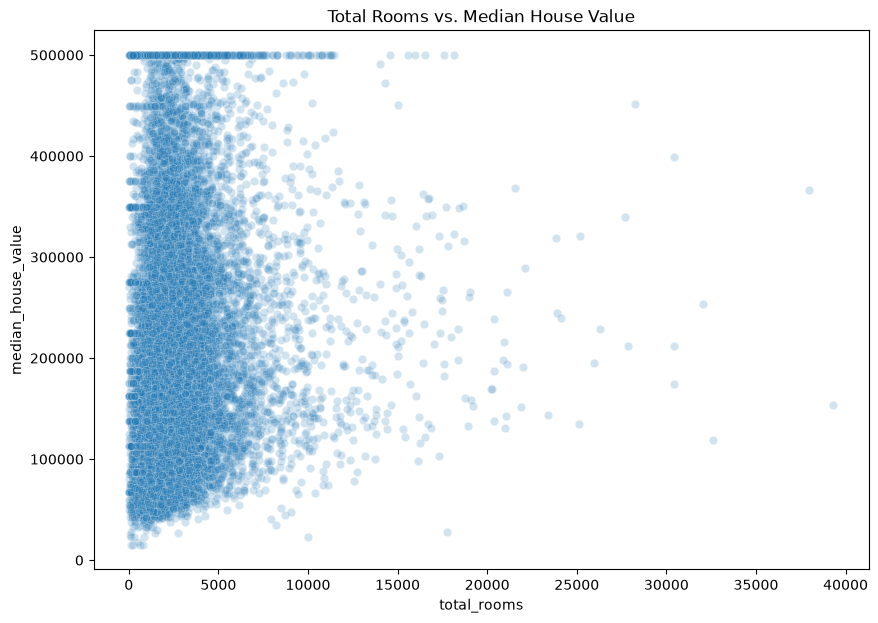

In [78]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_eda,
    x="total_rooms",
    y="median_house_value",
    alpha=0.2
)

plt.title("Total Rooms vs. Median House Value")
plt.show()

## Conclusions on Total Rooms vs. Median House Value

- There is a weak positive relationship between the total number of rooms and the median house value.

- Areas with more total rooms may have higher house values, but the relationship is not sufficiently strong or consistent.

- Most observations are concentrated in areas with a relatively low or medium number of total rooms.

- Areas with a similar number of total rooms can have considerably different house values.

- Some areas contain an unusually large number of rooms and may represent large districts rather than data errors.

- The `total_rooms` feature cannot describe the size of an individual house because it represents the total number of rooms in the entire area.

- A derived feature such as `rooms_per_household` may be more informative because it considers both the total number of rooms and the number of households in the area.


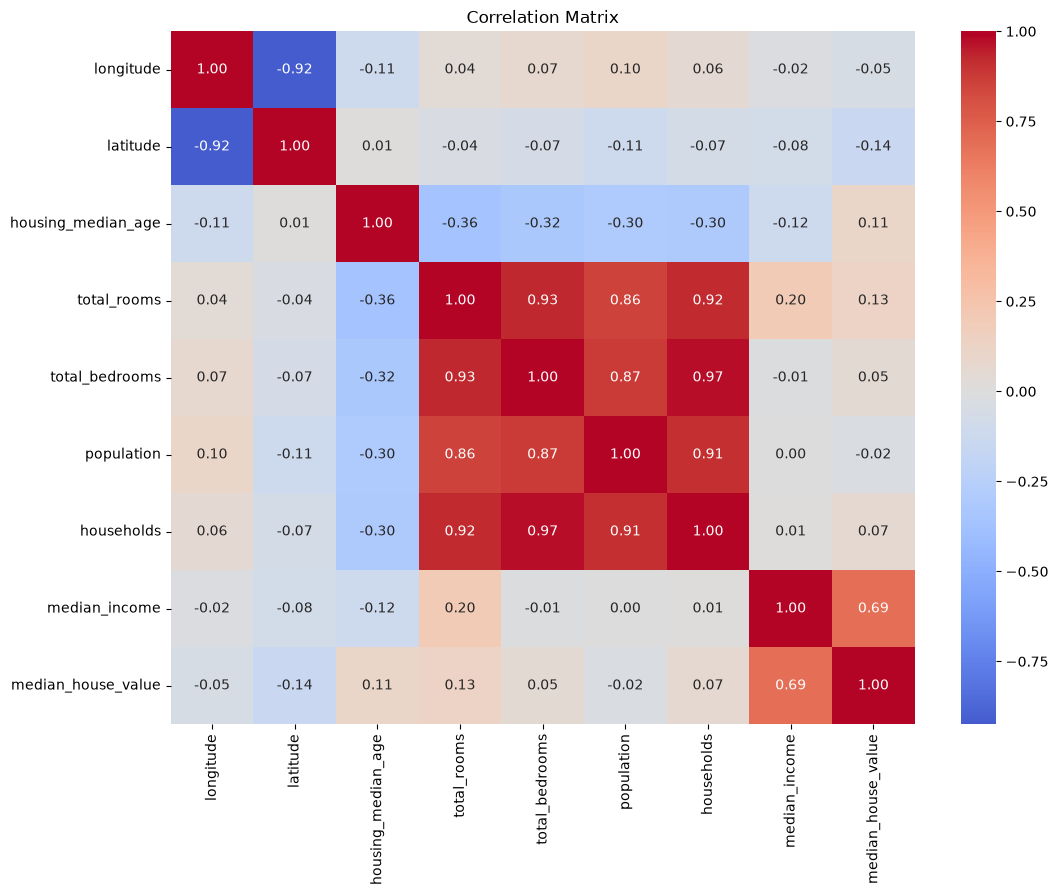

In [82]:
numeric_df = df_eda.select_dtypes(
    include=["int64", "float64"]
)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## Conclusions on the Correlation Matrix

- `median_income` has the strongest positive correlation with `median_house_value`, with a value of approximately **0.69**.

- This confirms that areas with higher median income generally tend to have higher house values.

- `latitude` has a weak negative correlation with house value, at approximately **−0.14**, while `longitude` has almost no direct linear correlation with the target.

- The low individual correlations of latitude and longitude do not mean that location is unimportant, because geographical position should be interpreted using both coordinates together.

- `total_rooms`, `total_bedrooms`, `population` and `households` are strongly correlated with one another because they all describe the size of a housing area.

- The strongest correlation between input features is observed between `total_bedrooms` and `households`, with a value of approximately **0.97**.

- The high correlations between the size-related features indicate that they may contain redundant information, so ratios such as `rooms_per_household` may be more informative.
